In [122]:

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import ks_2samp, wasserstein_distance
# 设置中文字体
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']   # Windows 推荐
mpl.rcParams['axes.unicode_minus'] = False

In [116]:

#D:\PycharmProjects\My_Paper_exe\Diffusion-Transformer
seq_len = 10000
base_dir = Path.cwd().parent
real_data_path = base_dir / "Data" / "datasets" / "traffic_data" / "data1" / "data.csv"
gen_data_path = base_dir / "Data" / "datasets" / "traffic_data" / "data2" / "data.csv"
#gen_data_path = base_dir / "OUTPUT" / "traffic_1" / "features" / "data_2.csv"
real_df = pd.read_csv(real_data_path, header=0)
real_df.drop(real_df.columns[0], axis=1, inplace=True)
#(117517, 3) int64
real_data = real_df.values
real_pkt_len = real_data[0:seq_len, 0]
real_iat = np.log1p(real_data[0:seq_len, 1])
real_dir = real_data[0:seq_len, 2]

gen_df = pd.read_csv(gen_data_path, header=0)
gen_df.drop(gen_df.columns[0], axis=1, inplace=True)
#(117517, 3) int64
gen_data = gen_df.values
gen_pkt_len = gen_data[0:seq_len, 0]
gen_iat = np.log1p(gen_data[0:seq_len, 1])
gen_dir = gen_data[0:seq_len, 2]

## 经验分布函数（ECDF） /KS /Wasserstein
pkt_len 的ECDF意义就是：
x：从小到大排列的包长度
y：长度不超过该值的数据包占总包数的比例

In [110]:

# =========================
# 2. 计算 ECDF
# =========================
def ecdf_values(x):
    x = np.sort(np.asarray(x))
    n = x.shape[0]
    y = np.arange(1, n + 1) / n
    return x, y

def ecdf_on_grid(x, grid):
    x = np.sort(np.asarray(x))
    n = x.shape[0]
    # 对每个 grid 点，计算 P(X <= grid_i)
    counts = np.searchsorted(x, grid, side='right')
    return counts / n


# =========================
# 3. 评估指标
# =========================
#分位数误差
def quantile_errors(real, gen, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]):
    result = {}
    for q in quantiles:
        qr = np.quantile(real, q)
        qg = np.quantile(gen, q)
        result[q] = {
            "real": float(qr),
            "gen": float(qg),
            "abs_error": float(abs(qr - qg))
        }
    return result
#固定阈值累计差异
def threshold_cdf_gaps(real, gen, thresholds=[64, 128, 256, 512, 1024, 1280, 1500]):
    result = {}
    real = np.asarray(real)
    gen = np.asarray(gen)
    for t in thresholds:
        Fr = np.mean(real <= t)
        Fg = np.mean(gen <= t)
        result[t] = {
            "real_cdf": float(Fr),
            "gen_cdf": float(Fg),
            "abs_gap": float(abs(Fr - Fg))
        }
    return result
#计算平均绝对差：
def mean_absolute_ecdf_gap(real, gen, grid=None):
    real = np.asarray(real)
    gen = np.asarray(gen)

    if grid is None:
        xmin = int(min(real.min(), gen.min()))
        xmax = int(max(real.max(), gen.max()))
        grid = np.arange(xmin, xmax + 1)

    Fr = ecdf_on_grid(real, grid)
    Fg = ecdf_on_grid(gen, grid)
    mae_gap = np.mean(np.abs(Fr - Fg))
    return float(mae_gap), grid, Fr, Fg

def evaluate_pkt_len_ecdf(real, gen):
    ks_stat, ks_pvalue = ks_2samp(real, gen)
    wass = wasserstein_distance(real, gen)
    mae_ecdf, grid, Fr, Fg = mean_absolute_ecdf_gap(real, gen)
    q_err = quantile_errors(real, gen)
    thr_gap = threshold_cdf_gaps(real, gen)

    return {
        "ks_stat": float(ks_stat),
        "ks_pvalue": float(ks_pvalue),
        "wasserstein": float(wass),
        "mae_ecdf": float(mae_ecdf),
        "grid": grid,
        "Fr": Fr,
        "Fg": Fg,
        "quantile_errors": q_err,
        "threshold_cdf_gaps": thr_gap,
    }


# =========================
# 4. 绘图
# =========================
def plot_ecdf(real, gen, title="ECDF of pkt_len"):
    xr, yr = ecdf_values(real)
    xg, yg = ecdf_values(gen)

    plt.figure(figsize=(8, 5))
    plt.step(xr, yr, where='post', label='Real')
    plt.step(xg, yg, where='post', label='Generated')
    plt.xlabel("pkt_len")
    plt.ylabel("ECDF")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_ecdf_gap(real, gen, title="ECDF Gap: F_gen(x) - F_real(x)"):
    _, grid, Fr, Fg = mean_absolute_ecdf_gap(real, gen)
    diff = Fg - Fr
    #diff = Fr -Fg
    plt.figure(figsize=(8, 5))
    plt.plot(grid, diff)
    plt.axhline(0, linestyle='--')
    plt.xlabel("pkt_len")
    plt.ylabel("F_gen(x) - F_real(x)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================
# 5. 打印结果
# =========================
def print_evaluation_report(metrics):
    print("===== ECDF Evaluation for pkt_len =====")
    print(f"KS statistic       : {metrics['ks_stat']:.6f}")
    # print(f"KS p-value         : {metrics['ks_pvalue']:.6e}")
    print(f"Wasserstein dist   : {metrics['wasserstein']:.6f}")
    # print(f"Mean Abs ECDF Gap  : {metrics['mae_ecdf']:.6f}")

    # print("\n--- Quantile Errors ---")
    # for q, v in metrics["quantile_errors"].items():
    #     print(f"q={q:>4}: real={v['real']:.2f}, gen={v['gen']:.2f}, abs_error={v['abs_error']:.2f}")
    #
    # print("\n--- Threshold CDF Gaps ---")
    # for t, v in metrics["threshold_cdf_gaps"].items():
    #     print(f"t={t:>4}: real_cdf={v['real_cdf']:.4f}, gen_cdf={v['gen_cdf']:.4f}, abs_gap={v['abs_gap']:.4f}")



#### ECDF差值图
Δ(x)=F^g​(x)−F^r​(x)
Δ(x)>0：生成分布在该长度前累计得更快，说明偏向更短包
Δ(x)<0：生成分布偏向更长包

#### KS statistic
两条 ECDF 最大垂直差，越小越好，只关注最坏点偏差，不能全面表示整体距离
#### Wasserstein distance（1维）
把一个分布“搬运”成另一个分布所需的平均代价。比 KS 更能反映整体偏差，数值大小需要结合数据范围解释，单位是字节


===== ECDF Evaluation for pkt_len =====
KS statistic       : 0.107600
Wasserstein dist   : 57.103100


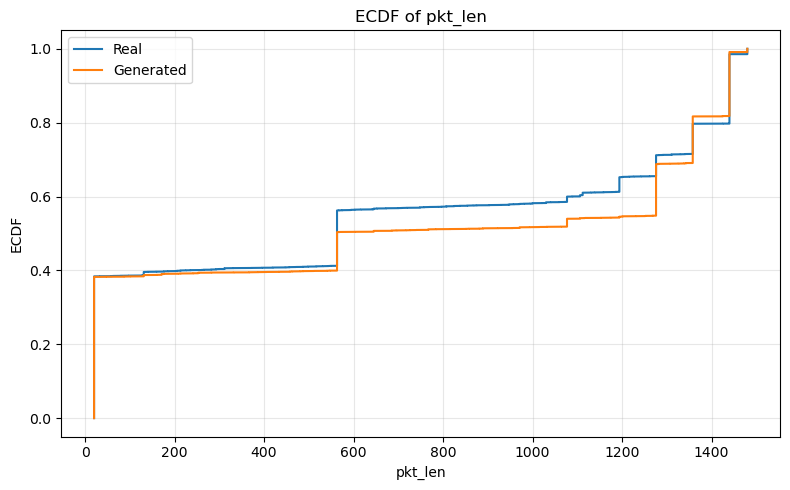

In [111]:
    metrics = evaluate_pkt_len_ecdf(real_pkt_len, gen_pkt_len)
    print_evaluation_report(metrics)

    plot_ecdf(real_pkt_len, gen_pkt_len)
    #plot_ecdf_gap(real_pkt_len, gen_pkt_len)

===== ECDF Evaluation for pkt_len =====
KS statistic       : 0.065000
Wasserstein dist   : 0.313371


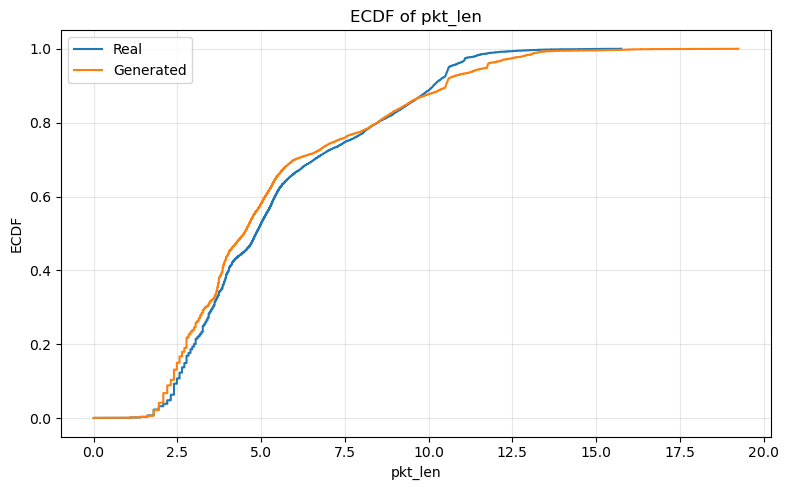

In [112]:
metrics = evaluate_pkt_len_ecdf(real_iat, gen_iat)
print_evaluation_report(metrics)

plot_ecdf(real_iat, gen_iat)
#plot_ecdf_gap(real_pkt_len, gen_pkt_len)

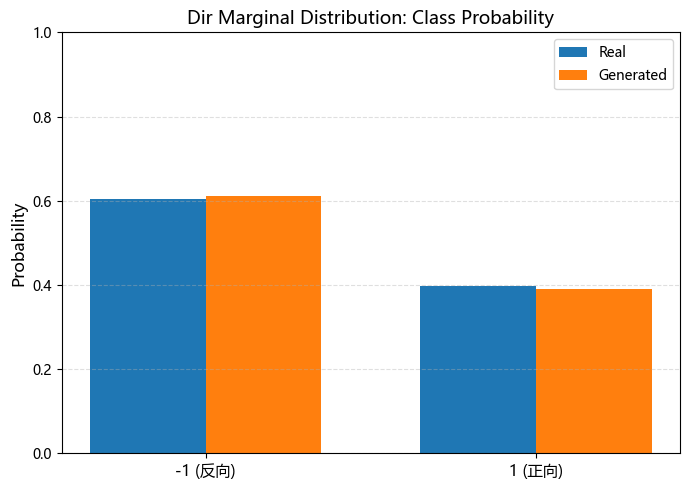

In [123]:
# =========================
# 3. 统计频数与概率
# =========================
def get_dir_stats(x):
    x = np.asarray(x).reshape(-1)
    count_neg = np.sum(x == -1)
    count_pos = np.sum(x == 1)
    total = x.shape[0]

    prob_neg = count_neg / total
    prob_pos = count_pos / total

    return {
        "count": np.array([count_neg, count_pos]),
        "prob": np.array([prob_neg, prob_pos])
    }

real_stats = get_dir_stats(real_dir)
gen_stats  = get_dir_stats(gen_dir)

labels = ['-1 (反向)', '1 (正向)']
x = np.arange(labels.__len__())
width = 0.35

# =========================
# 4. 类别概率条形图
# =========================
plt.figure(figsize=(7, 5))
plt.bar(x - width/2, real_stats["prob"], width, label='Real')
plt.bar(x + width/2, gen_stats["prob"], width, label='Generated')

plt.xticks(x, labels, fontsize=11)
plt.ylabel('Probability', fontsize=12)
plt.title('Dir Marginal Distribution: Class Probability', fontsize=13)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 直方图

In [113]:
def plot_pkt_len_frequency(
    real,
    gen,
    normalize=True,
    x_min=None,
    x_max=None,
    title="Frequency of exact pkt_len values"
):
    real = np.asarray(real).astype(int)
    gen = np.asarray(gen).astype(int)

    if x_min is None:
        x_min = int(min(real.min(), gen.min()))
    if x_max is None:
        x_max = int(max(real.max(), gen.max()))

    xs = np.arange(x_min, x_max + 1)

    real_counts = np.bincount(real - x_min, minlength=xs.shape[0])
    gen_counts  = np.bincount(gen - x_min, minlength=xs.shape[0])

    if normalize:
        real_y = real_counts / real_counts.sum()
        gen_y  = gen_counts / gen_counts.sum()
        ylabel = "Probability"
    else:
        real_y = real_counts
        gen_y  = gen_counts
        ylabel = "Count"

    plt.figure(figsize=(10, 5))
    plt.plot(xs, real_y, label="Real")
    plt.plot(xs, gen_y, label="Generated")
    plt.xlabel("pkt_len")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
def plot_histogram_overlay_fixed_bins(
    real,
    gen,
    bin_width=20,
    density=True,
    alpha=0.5,
    x_min=None,
    x_max=None,
    title="Histogram of pkt_len"
):
    real = np.asarray(real)
    gen = np.asarray(gen)

    if x_min is None:
        x_min = int(min(real.min(), gen.min()))
    if x_max is None:
        x_max = int(max(real.max(), gen.max()))

    bins = np.arange(x_min, x_max + bin_width, bin_width)

    plt.figure(figsize=(8, 5))
    plt.hist(real, bins=bins, density=density, alpha=alpha, label="Real")
    plt.hist(gen,  bins=bins, density=density, alpha=alpha, label="Generated")

    plt.xlabel("pkt_len")
    plt.ylabel("Density" if density else "Count")
    plt.title(title + f" (bin_width={bin_width})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

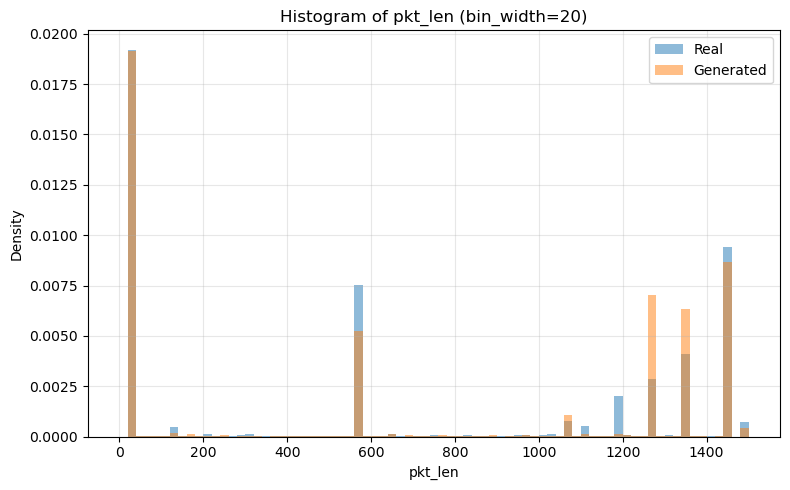

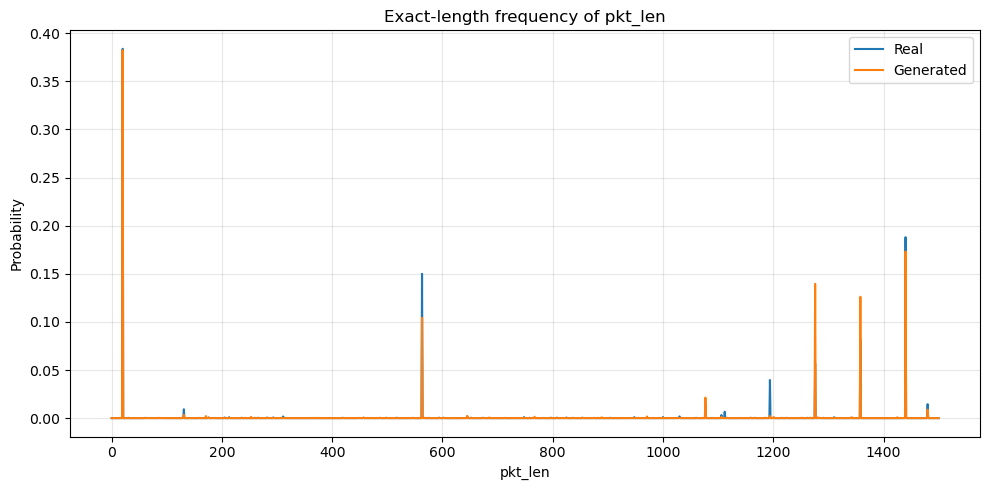

In [114]:
# 辅助展示1：整体 histogram
plot_histogram_overlay_fixed_bins(
    real_pkt_len,
    gen_pkt_len,
    bin_width=20,
    density=True,
    x_min=0,
    x_max=1500,
    title="Histogram of pkt_len"
)

# 辅助展示2：精确长度频率曲线
plot_pkt_len_frequency(
    real_pkt_len,
    gen_pkt_len,
    normalize=True,
    x_min=0,
    x_max=1500,
    title="Exact-length frequency of pkt_len"
)